In [2]:
from google.colab import files

# Upload file from your computer
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [5]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [9]:
df[['Order Date', 'Sales']].head()

,Order Date,Sales
0,2016-11-08,261.9600
1,2016-11-08,731.9400
2,2016-06-12,14.6200
3,2015-10-11,957.5775
4,2015-10-11,22.3680


In [10]:
sales_daily = df.groupby('Order Date')['Sales'].sum().reset_index()

sales_daily.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


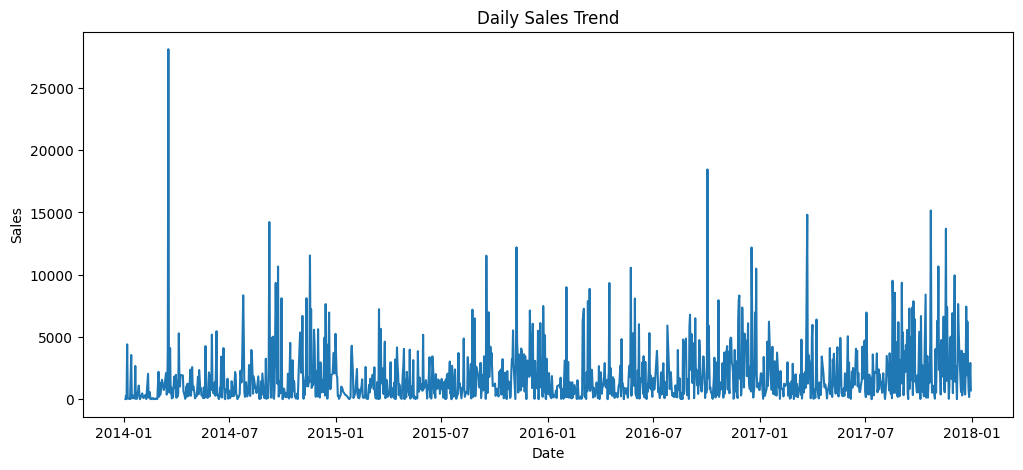

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    sales_daily['Order Date'],
    sales_daily['Sales']
)

plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()

In [13]:
sales_daily['Year'] = sales_daily['Order Date'].dt.year
sales_daily['Month'] = sales_daily['Order Date'].dt.month
sales_daily['Day'] = sales_daily['Order Date'].dt.day
sales_daily['DayOfWeek'] = sales_daily['Order Date'].dt.dayofweek

In [14]:
sales_daily.head()

,Order Date,Sales,Year,Month,Day,DayOfWeek
0,2014-01-03,16.448,2014,1,3,4
1,2014-01-04,288.060,2014,1,4,5
2,2014-01-05,19.536,2014,1,5,6
3,2014-01-06,4407.100,2014,1,6,0
4,2014-01-07,87.158,2014,1,7,1


In [15]:
sales_daily['Lag1'] = sales_daily['Sales'].shift(1)

sales_daily['Lag7'] = sales_daily['Sales'].shift(7)

sales_daily['Rolling7'] = sales_daily['Sales'].rolling(7).mean()

In [16]:
sales_daily = sales_daily.dropna()

In [17]:
sales_daily.head()

,Order Date,Sales,Year,Month,Day,DayOfWeek,Lag1,Lag7,Rolling7
7,2014-01-11,9.940,2014,1,11,5,54.830,16.448,701.024000
8,2014-01-13,3553.795,2014,1,13,0,9.940,288.060,1167.557571
9,2014-01-14,61.960,2014,1,14,1,3553.795,19.536,1173.618143
10,2014-01-15,149.950,2014,1,15,2,61.960,4407.100,565.453857
11,2014-01-16,299.964,2014,1,16,3,149.950,87.158,595.854714


In [18]:
train_size = int(len(sales_daily) * 0.8)

train = sales_daily[:train_size]

test = sales_daily[train_size:]

In [20]:
features = [
    'Year',
    'Month',
    'Day',
    'DayOfWeek',
    'Lag1',
    'Lag7',
    'Rolling7'
]

X_train = train[features]
y_train = train['Sales']

X_test = test[features]
y_test = test['Sales']

In [21]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [22]:
predictions = model.predict(X_test)

predictions[:5]

array([2883.52665 , 3293.397869, 2216.218054, 1075.33948 , 1210.718165])

In [23]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

print("MAE =", mae)
print("RMSE =", rmse)

MAE = 1730.5869097723576
RMSE = 2323.23810397849


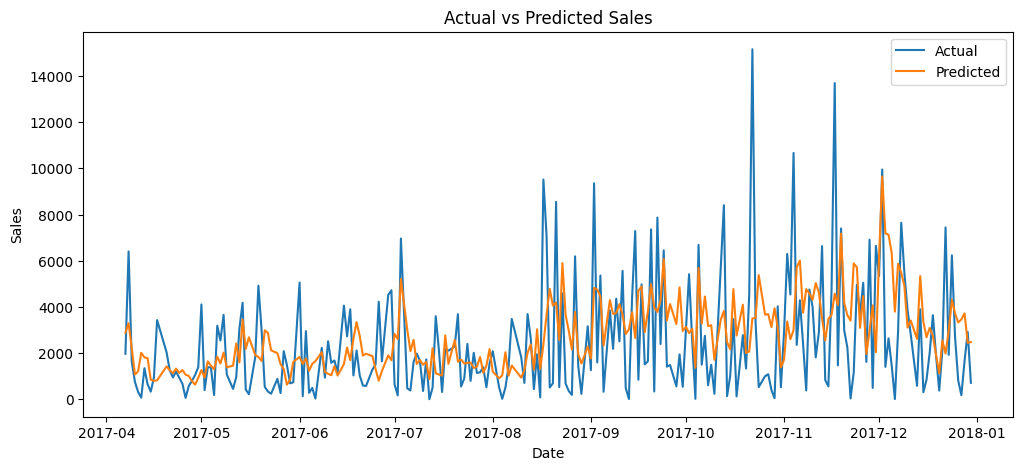

In [24]:
plt.figure(figsize=(12,5))

plt.plot(
    test['Order Date'],
    y_test,
    label='Actual'
)

plt.plot(
    test['Order Date'],
    predictions,
    label='Predicted'
)

plt.title('Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.show()

In [25]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(importance)

     Feature  Importance
6   Rolling7    0.401301
4       Lag1    0.164201
5       Lag7    0.160582
2        Day    0.119602
3  DayOfWeek    0.073832
1      Month    0.051207
0       Year    0.029274


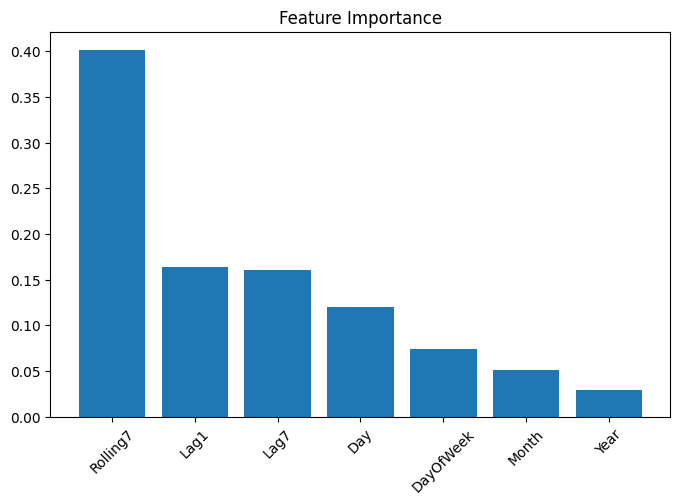

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title('Feature Importance')
plt.xticks(rotation=45)

plt.show()

In [29]:
last_date = sales_daily['Order Date'].max()

future_dates = pd.date_range(
    start=last_date,
    periods=31,
    freq='D'
)[1:]

future_df = pd.DataFrame({
    'Order Date': future_dates
})

future_df['Year'] = future_df['Order Date'].dt.year
future_df['Month'] = future_df['Order Date'].dt.month
future_df['Day'] = future_df['Order Date'].dt.day
future_df['DayOfWeek'] = future_df['Order Date'].dt.dayofweek

In [31]:
last_sales = sales_daily['Sales'].iloc[-1]

future_df['Lag1'] = last_sales
future_df['Lag7'] = last_sales
future_df['Rolling7'] = last_sales

In [32]:
future_predictions = model.predict(
    future_df[features]
)

future_df['Forecast Sales'] = future_predictions

future_df.head()

,Order Date,Year,Month,Day,DayOfWeek,Lag1,Lag7,Rolling7,Forecast Sales
0,2017-12-31,2017,12,31,6,713.79,713.79,713.79,937.994470
1,2018-01-01,2018,1,1,0,713.79,713.79,713.79,949.881048
2,2018-01-02,2018,1,2,1,713.79,713.79,713.79,911.974204
3,2018-01-03,2018,1,3,2,713.79,713.79,713.79,892.728400
4,2018-01-04,2018,1,4,3,713.79,713.79,713.79,914.490390


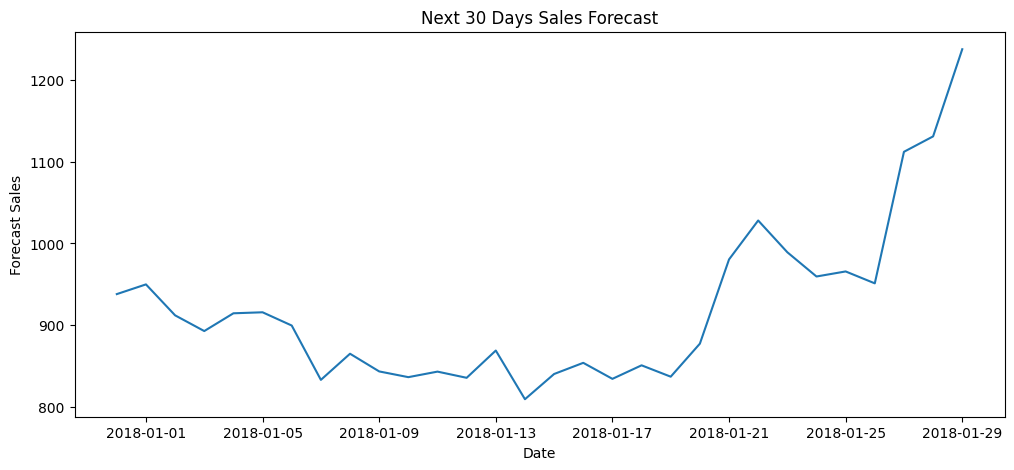

In [33]:
plt.figure(figsize=(12,5))

plt.plot(
    future_df['Order Date'],
    future_df['Forecast Sales']
)

plt.title('Next 30 Days Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Forecast Sales')

plt.show()

In [34]:
print(
    "Average Forecasted Daily Sales:",
    future_df['Forecast Sales'].mean()
)

print(
    "Maximum Forecasted Sales:",
    future_df['Forecast Sales'].max()
)

print(
    "Minimum Forecasted Sales:",
    future_df['Forecast Sales'].min()
)

Average Forecasted Daily Sales: 920.1692355666669
Maximum Forecasted Sales: 1237.9724199999991
Minimum Forecasted Sales: 809.225315
